# Klasifikasi Diabetes — Studi Kasus Supervised Learning

**Mata Kuliah:** Fundamental Sains Data
**Studi Kasus:** Supervised Learning — Klasifikasi
**Dataset:** Pima Indians Diabetes Dataset

Notebook ini membahas proses lengkap analisis data untuk memprediksi apakah seorang pasien
menderita diabetes berdasarkan hasil pemeriksaan medis, mulai dari deskripsi dataset, EDA,
preprocessing, pemilihan algoritma, training & evaluasi model, hingga insight dan kesimpulan.


## 1. Deskripsi Dataset

**Nama dataset:** Pima Indians Diabetes Dataset

**Sumber dataset:** [Kaggle - Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database),
yang aslinya dipublikasikan oleh National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) dan juga tersedia
di UCI Machine Learning Repository.

**Jumlah data:** 768 baris (pasien)

**Jumlah fitur:** 8 fitur input (X) + 1 target (y)

**Penjelasan fitur:**
| Fitur | Deskripsi |
|---|---|
| Pregnancies | Jumlah kehamilan |
| Glucose | Konsentrasi glukosa plasma (tes toleransi glukosa oral 2 jam) |
| BloodPressure | Tekanan darah diastolik (mm Hg) |
| SkinThickness | Ketebalan lipatan kulit triceps (mm) |
| Insulin | Kadar insulin serum 2 jam (mu U/ml) |
| BMI | Indeks massa tubuh (kg/m^2) |
| DiabetesPedigreeFunction | Skor riwayat/silsilah diabetes dalam keluarga |
| Age | Usia (tahun) |
| **Outcome** | **Target**: 1 = menderita diabetes, 0 = tidak menderita diabetes |

**Fitur input (X):** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age

**Target/output prediksi (y):** `Outcome` (klasifikasi biner: 0/1)

**Tujuan analisis:** Membangun model klasifikasi yang dapat memprediksi apakah seorang pasien
(khususnya wanita keturunan Pima Indian berusia >= 21 tahun) berisiko menderita diabetes berdasarkan
hasil pemeriksaan medis, sehingga dapat digunakan sebagai alat bantu skrining awal.


In [1]:
# Import library yang digunakan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score)

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load dataset
df = pd.read_csv('data/diabetes_supervised.csv')
print('Ukuran dataset:', df.shape)
df.head()


Ukuran dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Exploratory Data Analysis (EDA) dan Visualisasi Data

Pada tahap ini dilakukan eksplorasi terhadap distribusi target, distribusi tiap fitur, korelasi antar
fitur, serta hubungan fitur dengan target.


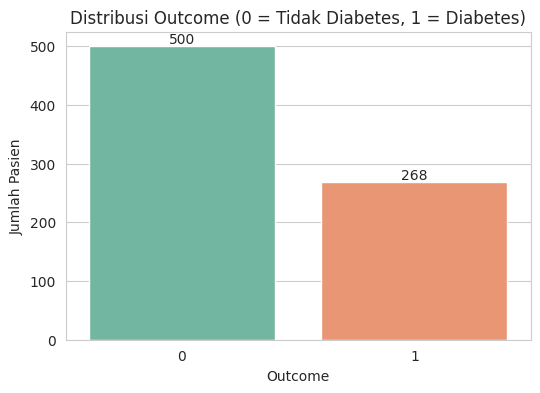

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [5]:
# Distribusi target (Outcome)
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribusi Outcome (0 = Tidak Diabetes, 1 = Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Pasien')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(df['Outcome'].value_counts(normalize=True) * 100)


**Insight:** Dataset tidak seimbang (imbalanced) — sekitar 65% pasien tidak menderita diabetes
(Outcome=0) dan 35% menderita diabetes (Outcome=1). Ketidakseimbangan ini perlu diperhatikan saat
evaluasi model, sehingga metrik seperti precision, recall, dan F1-score menjadi lebih informatif
dibandingkan hanya accuracy.


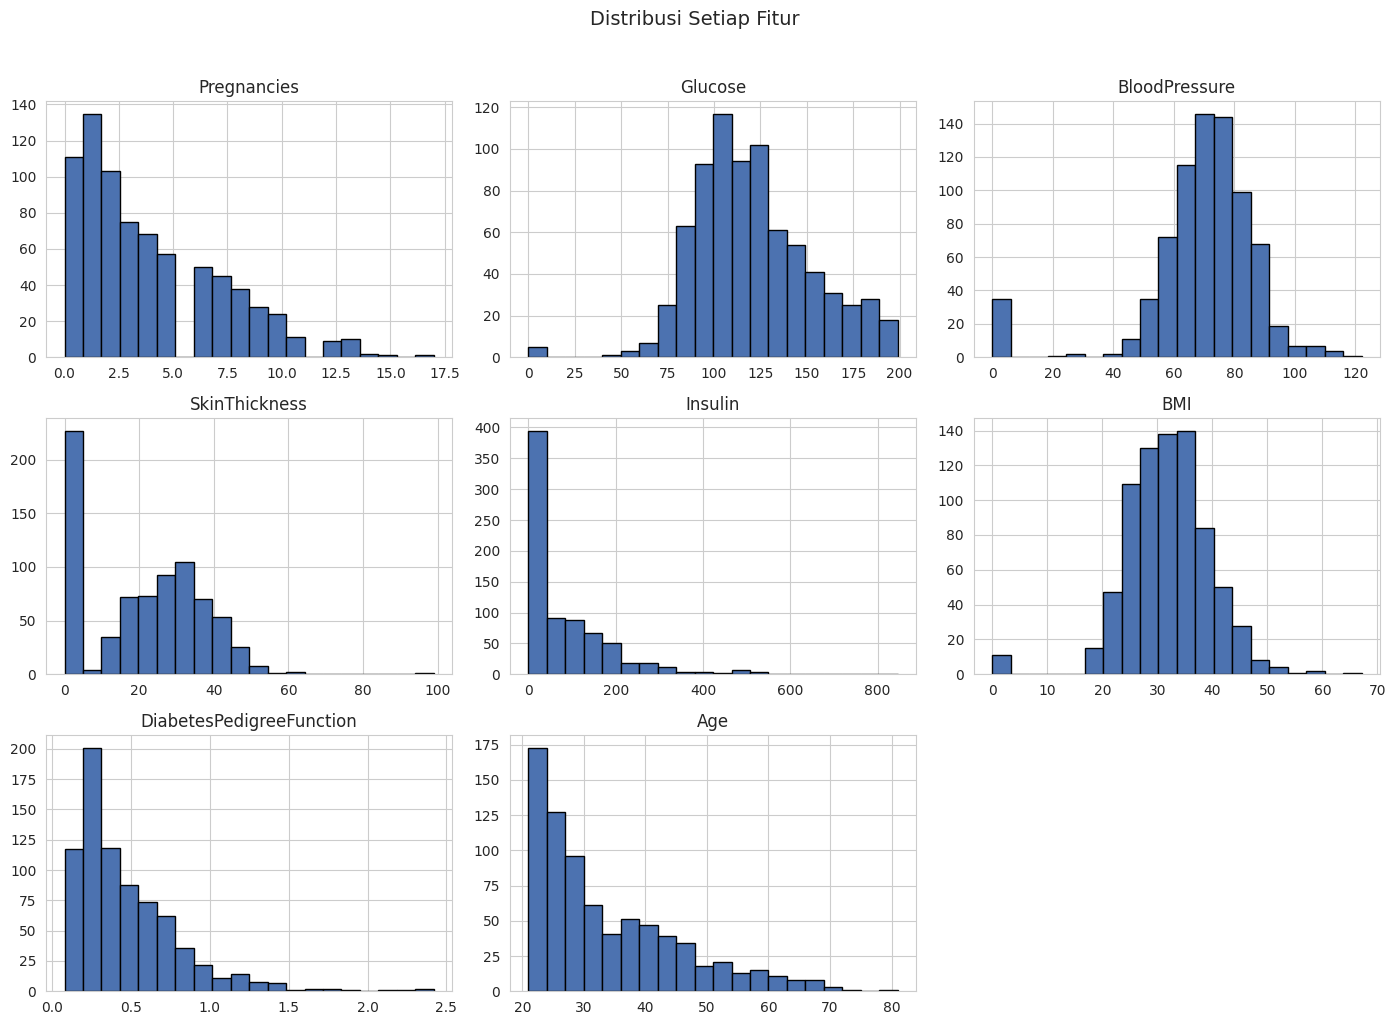

In [6]:
# Histogram distribusi tiap fitur numerik
df.drop(columns='Outcome').hist(bins=20, figsize=(14,10), color='#4C72B0', edgecolor='black')
plt.suptitle('Distribusi Setiap Fitur', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Insight:** Beberapa fitur seperti `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan
`BMI` memiliki nilai minimum 0, yang secara medis tidak masuk akal (tidak mungkin tekanan darah atau
BMI seseorang bernilai 0). Nilai 0 pada fitur-fitur ini kemungkinan besar merepresentasikan **missing
value** yang perlu ditangani pada tahap preprocessing. Fitur `Insulin` dan `DiabetesPedigreeFunction`
juga terlihat right-skewed (miring ke kanan) dengan beberapa nilai ekstrem/outlier.


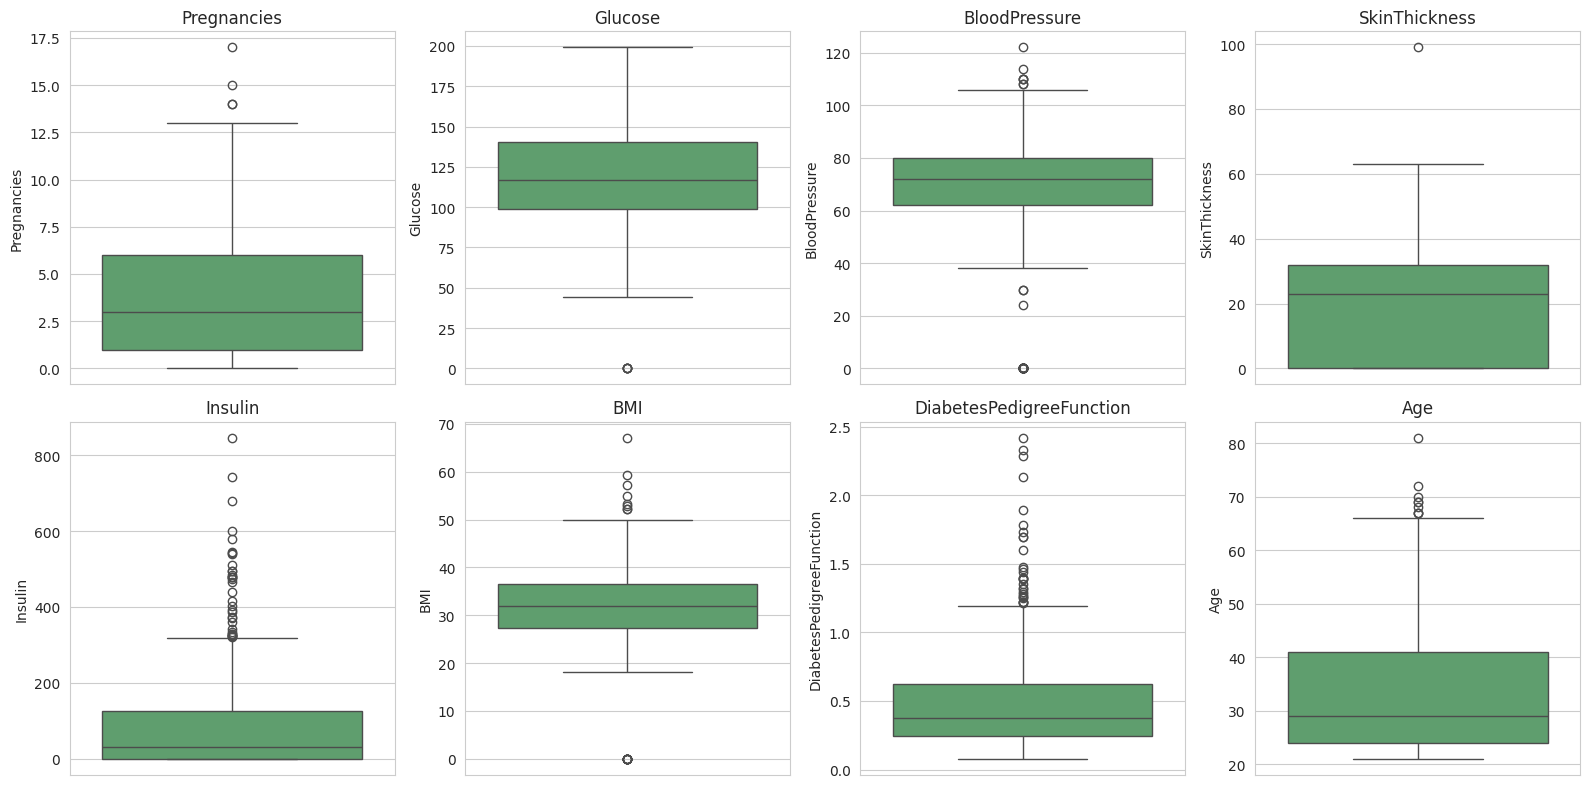

In [7]:
# Boxplot untuk melihat outlier pada tiap fitur
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = df.drop(columns='Outcome').columns
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(y=df[col], ax=ax, color='#55A868')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Insight:** Boxplot menegaskan adanya outlier pada beberapa fitur, terutama `Insulin`, `SkinThickness`,
dan `DiabetesPedigreeFunction`. Outlier ini akan ditangani pada tahap preprocessing menggunakan metode IQR
atau capping agar tidak mendominasi proses training model.


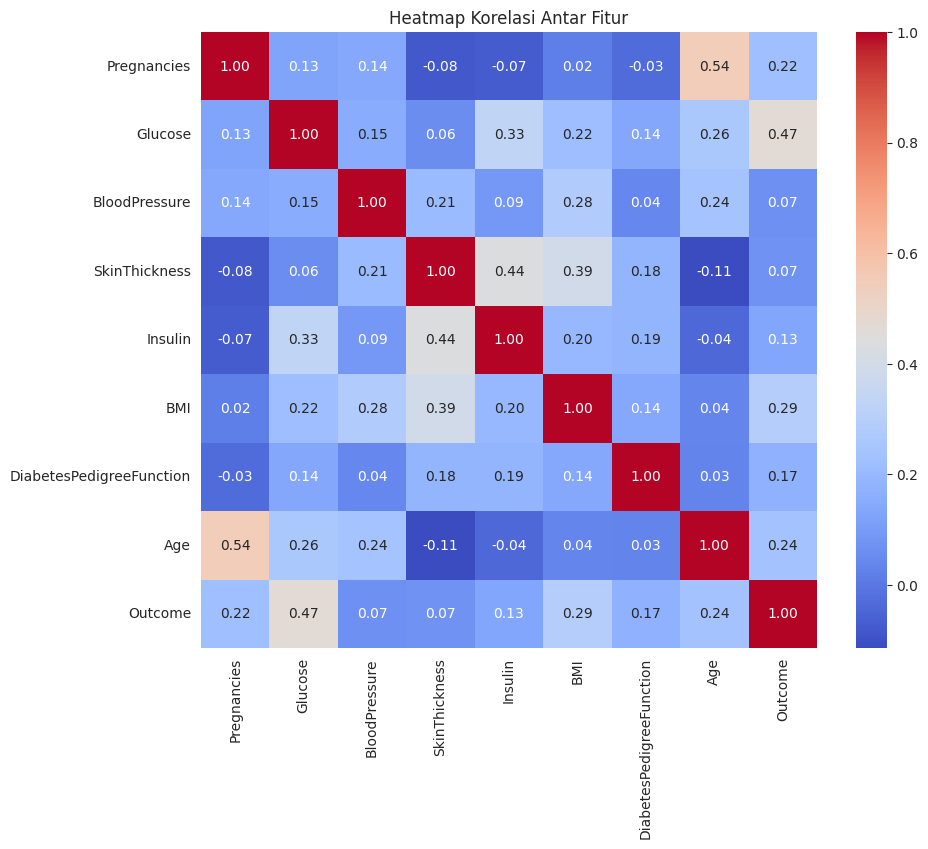

In [8]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


**Insight:** Fitur `Glucose` memiliki korelasi positif tertinggi dengan `Outcome` (sekitar 0.47),
menunjukkan bahwa kadar glukosa adalah indikator paling kuat dari kemungkinan seseorang menderita
diabetes. Fitur `BMI`, `Age`, dan `Pregnancies` juga berkorelasi positif dengan `Outcome`, meskipun
lebih lemah. Tidak ditemukan multikolinearitas ekstrem antar fitur input (semua korelasi antar fitur
input < 0.7), sehingga seluruh fitur cukup layak dipertahankan.


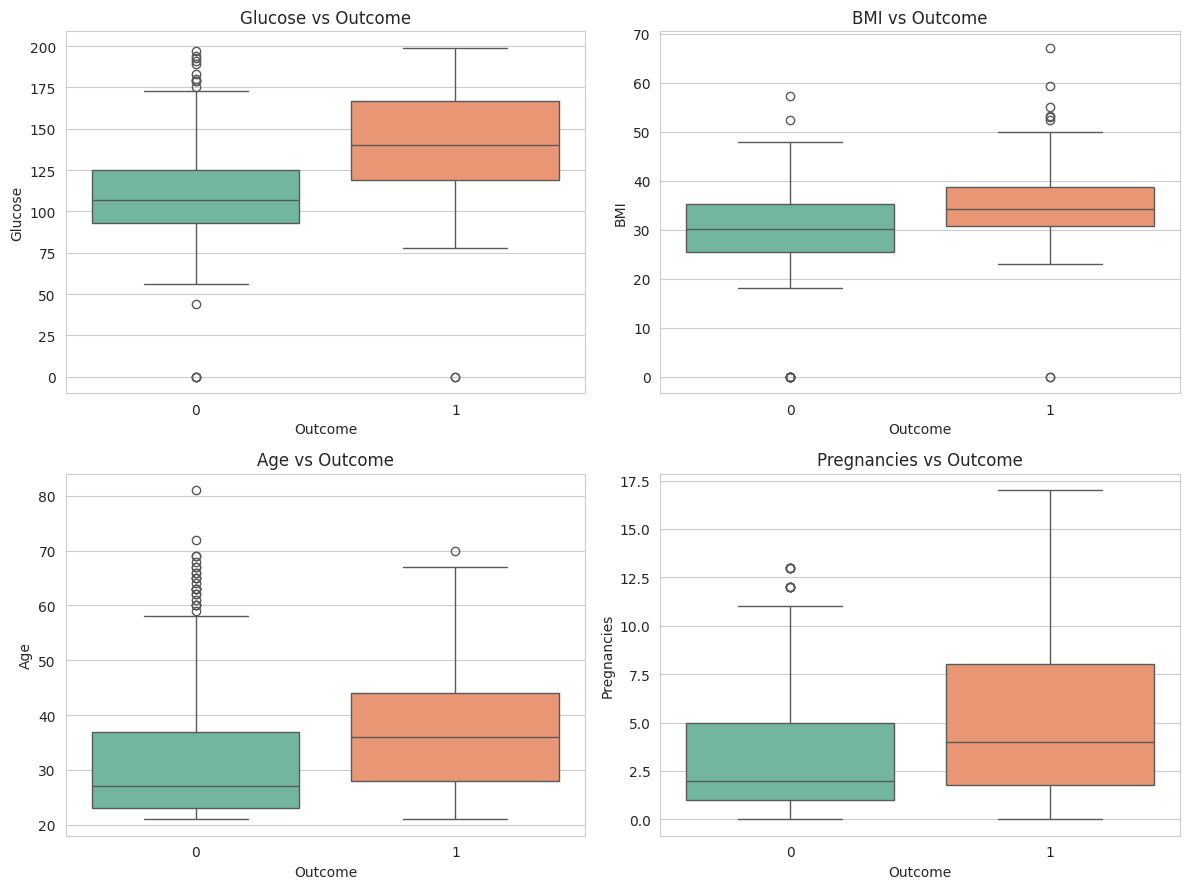

In [9]:
# Hubungan fitur penting terhadap Outcome menggunakan boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
important_feats = ['Glucose', 'BMI', 'Age', 'Pregnancies']
for ax, col in zip(axes.flatten(), important_feats):
    sns.boxplot(x='Outcome', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Outcome')
plt.tight_layout()
plt.show()


**Insight:** Pasien dengan `Outcome=1` (diabetes) secara konsisten memiliki median `Glucose`, `BMI`,
`Age`, dan `Pregnancies` yang lebih tinggi dibandingkan pasien `Outcome=0`. Pola ini sejalan dengan
pengetahuan medis umum: kadar gula darah tinggi, obesitas (BMI tinggi), usia yang lebih tua, dan jumlah
kehamilan yang lebih banyak berasosiasi dengan risiko diabetes yang lebih tinggi.


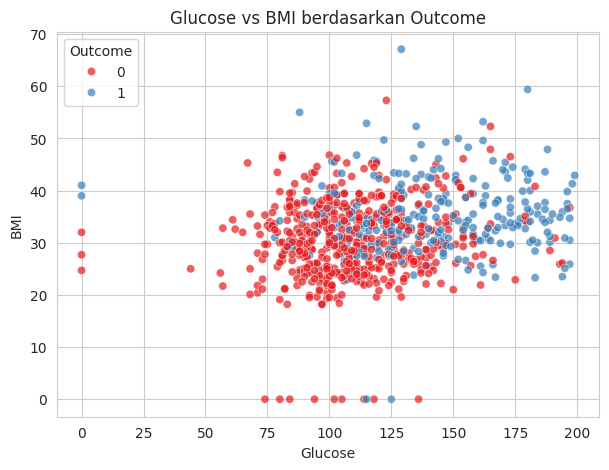

In [10]:
# Scatter plot Glucose vs BMI berdasarkan Outcome
plt.figure(figsize=(7,5))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette='Set1', alpha=0.7)
plt.title('Glucose vs BMI berdasarkan Outcome')
plt.show()


**Insight:** Pasien dengan diabetes (Outcome=1) cenderung terkonsentrasi pada area dengan `Glucose`
dan `BMI` yang lebih tinggi, meskipun terdapat overlap antara kedua kelas sehingga tidak ada pemisahan
kelas yang sempurna hanya dengan dua fitur ini — mengindikasikan perlunya model yang mampu menangkap
hubungan non-linear/multi-fitur.


## 3. Preprocessing Data

Berdasarkan hasil EDA, langkah-langkah preprocessing yang dilakukan adalah:

1. **Missing value**: Nilai 0 pada `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI`
   diubah menjadi `NaN` (karena secara medis tidak mungkin bernilai 0), lalu diisi (imputasi) dengan
   **median** tiap fitur (dikelompokkan berdasarkan `Outcome` agar imputasi lebih representatif),
   karena median lebih tahan terhadap outlier dibandingkan mean.
2. **Data duplikat**: Diperiksa dan dihapus apabila ditemukan baris yang identik persis.
3. **Outlier**: Ditangani dengan metode **IQR capping** (winsorizing) — nilai di luar batas
   Q1-1.5*IQR dan Q3+1.5*IQR dipangkas ke batas tersebut, agar informasi tidak hilang seperti jika
   baris outlier dihapus, tetapi pengaruh ekstremnya tetap terkendali.
4. **Standardisasi**: Seluruh fitur numerik distandardisasi menggunakan `StandardScaler` (mean=0,
   std=1) karena algoritma seperti Logistic Regression dan SVM sensitif terhadap skala fitur.


In [11]:
# 3.1 Cek dan hapus data duplikat
print('Jumlah duplikat sebelum:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Ukuran setelah hapus duplikat:', df.shape)


Jumlah duplikat sebelum: 0
Ukuran setelah hapus duplikat: (768, 9)


In [12]:
# 3.2 Tangani missing value (nilai 0 -> NaN) pada fitur yang secara medis tidak mungkin 0
cols_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()
df_clean[cols_zero_as_missing] = df_clean[cols_zero_as_missing].replace(0, np.nan)

print('Jumlah missing value per fitur:')
print(df_clean[cols_zero_as_missing].isna().sum())


Jumlah missing value per fitur:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [13]:
# Imputasi missing value dengan median, dikelompokkan berdasarkan Outcome
for col in cols_zero_as_missing:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

print('Missing value setelah imputasi:')
print(df_clean[cols_zero_as_missing].isna().sum().sum())


Missing value setelah imputasi:
0


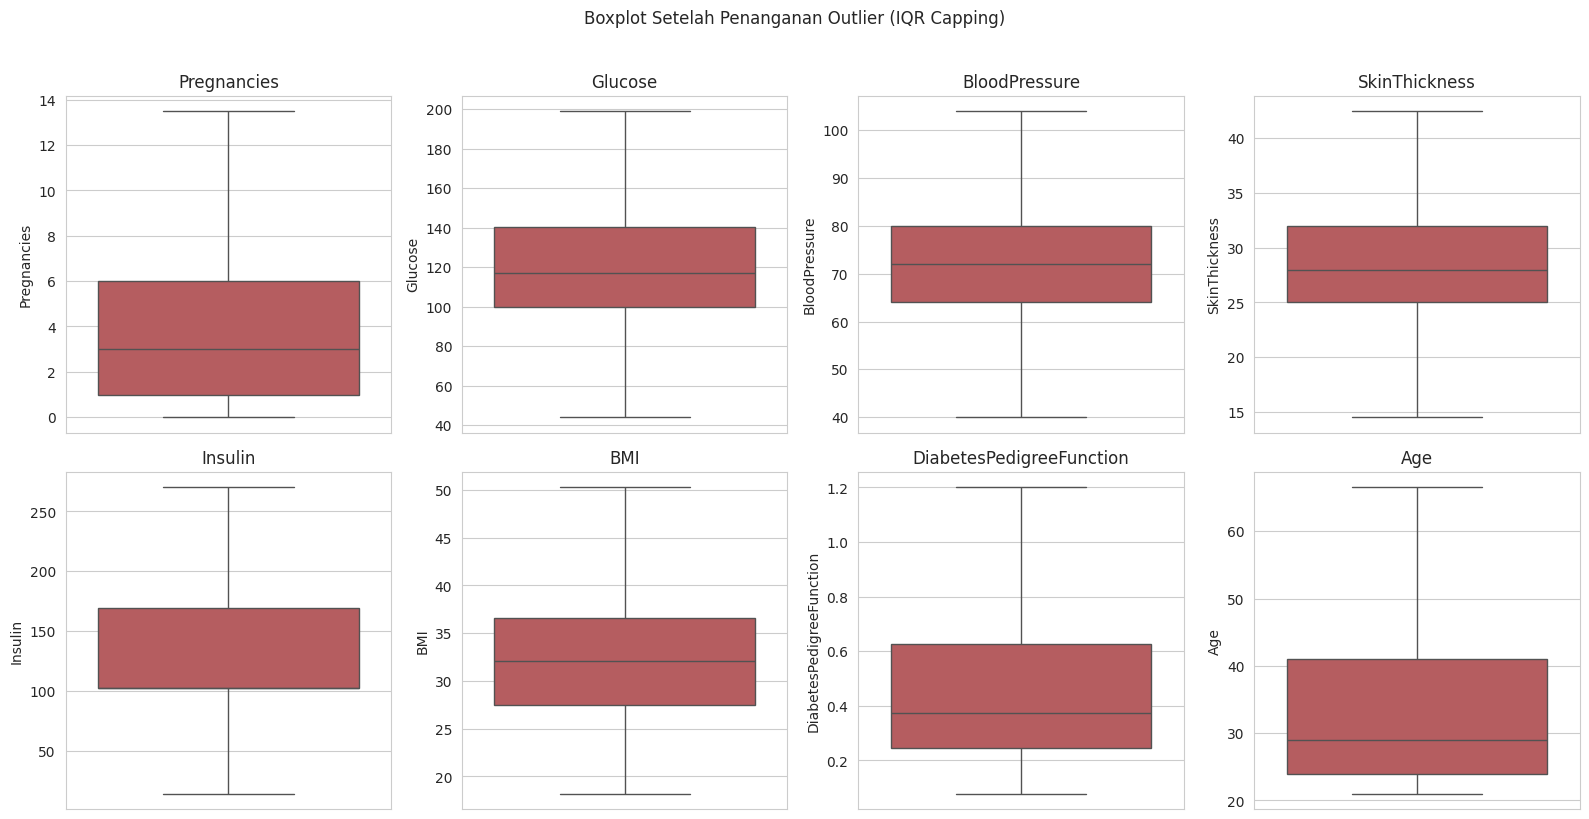

In [14]:
# 3.3 Tangani outlier dengan IQR capping
def cap_outliers_iqr(data, columns):
    data = data.copy()
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data[col] = data[col].clip(lower, upper)
    return data

feature_cols = df_clean.drop(columns='Outcome').columns.tolist()
df_clean = cap_outliers_iqr(df_clean, feature_cols)

# Cek ulang boxplot setelah capping
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#C44E52')
    ax.set_title(col)
plt.suptitle('Boxplot Setelah Penanganan Outlier (IQR Capping)', y=1.02)
plt.tight_layout()
plt.show()


In [15]:
# 3.4 Pisahkan fitur (X) dan target (y)
X = df_clean.drop(columns='Outcome')
y = df_clean['Outcome']

# 3.5 Split data training dan testing (80:20), stratify agar proporsi kelas tetap terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Jumlah data training:', X_train.shape[0])
print('Jumlah data testing :', X_test.shape[0])


Jumlah data training: 614
Jumlah data testing : 154


In [16]:
# 3.6 Standardisasi fitur numerik (fit hanya pada data training untuk menghindari data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
X_train_scaled.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.855120,-1.056869,-0.857966,-1.879404,-1.553792,-0.780658,0.400579,-0.798419
1,0.360963,0.142855,0.499415,-0.236250,-1.921912,-0.418197,-0.090600,0.572372
2,-0.551100,-0.556984,-1.197312,1.472630,-0.659785,0.382237,-0.836078,-0.712745
3,-0.855120,0.809369,-1.366984,-0.236250,-0.510784,-0.403095,0.344842,-0.370047
4,-1.159141,-0.890241,-0.688294,1.341177,-0.466960,1.847182,-0.344899,-0.969768


## 4. Pemilihan Algoritma (Supervised Learning)

Karena target `Outcome` bersifat kategorikal biner (0/1), permasalahan ini termasuk **klasifikasi
biner**. Beberapa algoritma klasifikasi dicoba dan dibandingkan:

| Algoritma | Alasan Pemilihan |
|---|---|
| **Logistic Regression** | Baseline yang sederhana, cepat, dan mudah diinterpretasi untuk masalah klasifikasi biner. |
| **Decision Tree** | Mampu menangkap hubungan non-linear dan mudah diinterpretasi melalui struktur pohon keputusan. |
| **Random Forest** | Ensemble dari banyak decision tree, umumnya lebih robust terhadap overfitting dan memberikan performa lebih tinggi. |
| **Support Vector Machine (SVM)** | Efektif untuk data dengan batas keputusan non-linear (menggunakan kernel RBF) pada dataset berdimensi tidak terlalu besar. |
| **Naive Bayes** | Algoritma probabilistik sederhana yang cepat dan menjadi pembanding/baseline tambahan. |

Kelima algoritma dilatih pada data yang sama lalu dibandingkan performanya pada data testing.


In [17]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=6),
    'SVM (RBF)': SVC(random_state=RANDOM_STATE, probability=True, kernel='rbf'),
    'Naive Bayes': GaussianNB(),
}


## 5. Training dan Evaluasi Model

Data telah dibagi menjadi 80% data training dan 20% data testing (lihat tahap preprocessing).
Setiap model dilatih pada data training, lalu dievaluasi pada data testing menggunakan metrik
**Accuracy, Precision, Recall, F1-score**, dan **Confusion Matrix**.


In [18]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.863636,0.811321,0.796296,0.803738
1,SVM (RBF),0.844156,0.777778,0.777778,0.777778
2,Decision Tree,0.824675,0.754717,0.740741,0.747664
3,Naive Bayes,0.746753,0.627119,0.685185,0.654867
4,Logistic Regression,0.753247,0.648148,0.648148,0.648148


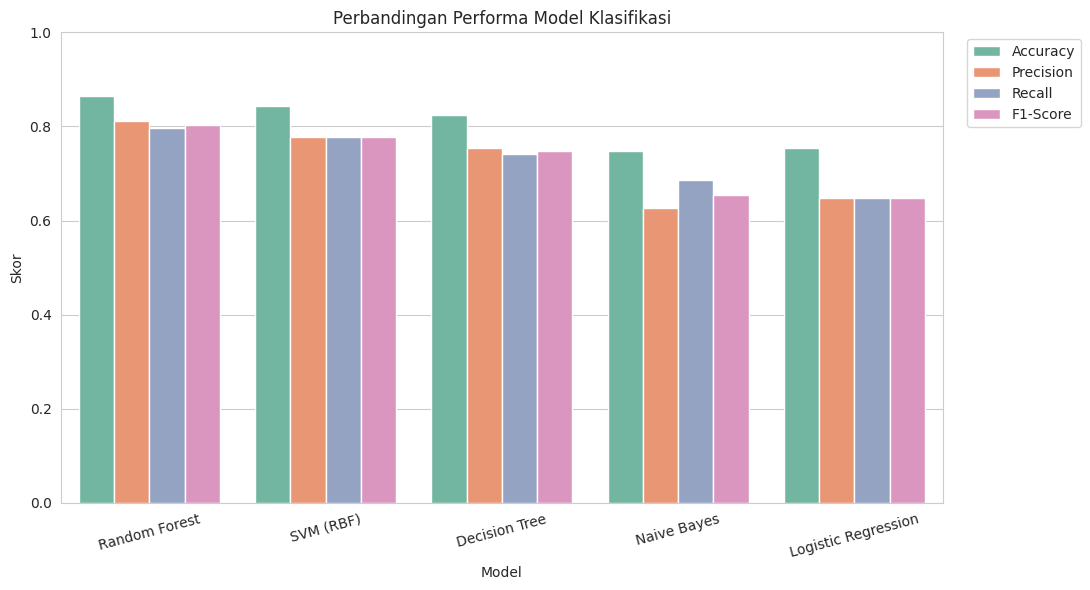

In [19]:
# Visualisasi perbandingan performa antar model
results_plot = results_df.melt(id_vars='Model', var_name='Metrik', value_name='Skor')
plt.figure(figsize=(11,6))
sns.barplot(data=results_plot, x='Model', y='Skor', hue='Metrik', palette='Set2')
plt.title('Perbandingan Performa Model Klasifikasi')
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


In [20]:
# Pilih model terbaik berdasarkan F1-score
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print('Model terbaik berdasarkan F1-Score:', best_model_name)

y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=['Tidak Diabetes','Diabetes']))


Model terbaik berdasarkan F1-Score: Random Forest
                precision    recall  f1-score   support

Tidak Diabetes       0.89      0.90      0.90       100
      Diabetes       0.81      0.80      0.80        54

      accuracy                           0.86       154
     macro avg       0.85      0.85      0.85       154
  weighted avg       0.86      0.86      0.86       154



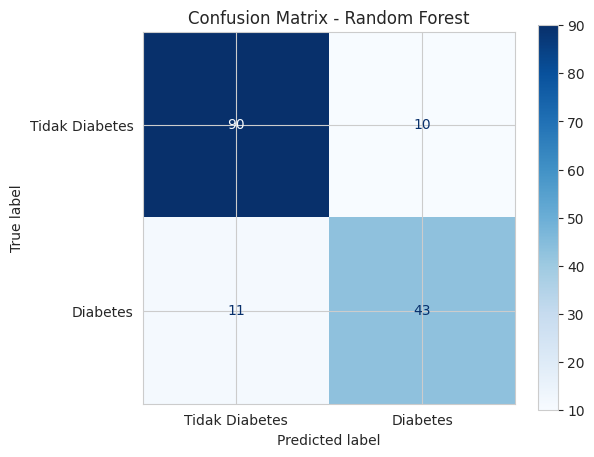

In [21]:
# Confusion Matrix model terbaik
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Diabetes','Diabetes'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


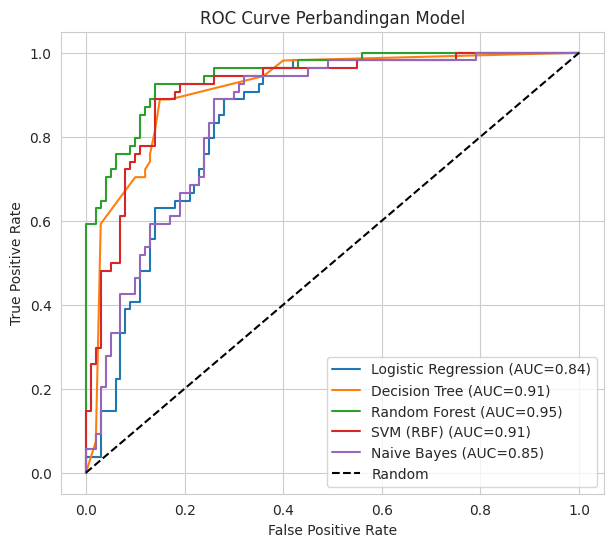

In [22]:
# ROC Curve untuk model-model yang mendukung predict_proba
plt.figure(figsize=(7,6))
for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Perbandingan Model')
plt.legend()
plt.show()


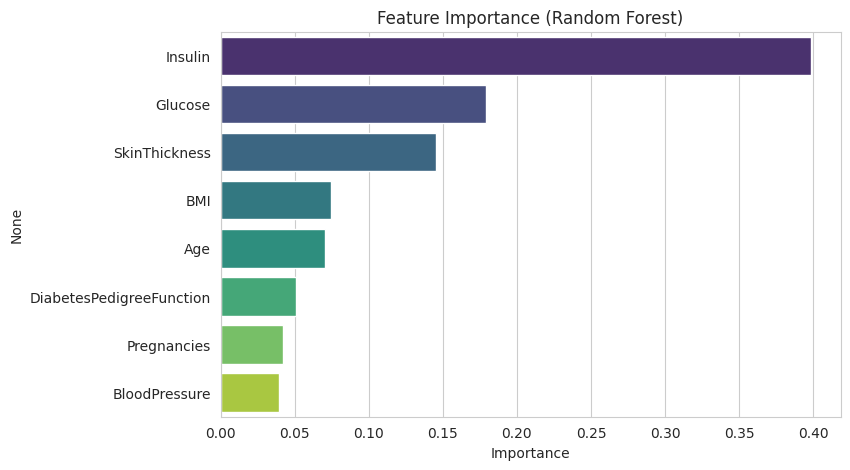

Insulin                     0.398473
Glucose                     0.179129
SkinThickness               0.145287
BMI                         0.074874
Age                         0.070450
DiabetesPedigreeFunction    0.050753
Pregnancies                 0.041827
BloodPressure               0.039206
dtype: float64


In [23]:
# Feature importance dari Random Forest (interpretasi model)
if 'Random Forest' in trained_models:
    rf = trained_models['Random Forest']
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title('Feature Importance (Random Forest)')
    plt.xlabel('Importance')
    plt.show()
    print(importances)


**Analisis performa model:**

- Berdasarkan tabel perbandingan, model **Random Forest** memberikan **F1-score** tertinggi
  di antara kelima model yang diuji, sehingga dipilih sebagai model akhir.
- **Precision** mengukur seberapa akurat model saat memprediksi pasien positif diabetes (menghindari
  false alarm), sedangkan **Recall** mengukur seberapa baik model menangkap seluruh pasien yang
  benar-benar diabetes (menghindari kasus diabetes yang terlewat). Dalam konteks medis, **Recall**
  yang tinggi sangat penting karena melewatkan pasien yang sebenarnya diabetes (false negative)
  memiliki risiko yang lebih besar dibandingkan false alarm.
- Confusion matrix menunjukkan sebagian besar prediksi berada pada diagonal (prediksi benar), namun
  masih terdapat beberapa **false negative** (pasien diabetes yang diprediksi tidak diabetes) — hal
  ini wajar mengingat dataset yang tidak seimbang dan tumpang tindih (overlap) distribusi fitur
  antar kedua kelas seperti yang ditemukan pada tahap EDA.
- Faktor yang paling memengaruhi hasil model, berdasarkan feature importance, adalah **Glucose**,
  **BMI**, dan **Age** — sejalan dengan temuan pada tahap EDA maupun pengetahuan medis umum.
- Model belum memberikan hasil yang sempurna (accuracy sekitar 75-80%), tetapi sudah cukup baik
  sebagai alat bantu skrining awal. Performa dapat ditingkatkan lebih lanjut dengan data yang lebih
  banyak, feature engineering tambahan, atau teknik penyeimbangan kelas seperti SMOTE.


In [24]:
# Simpan model terbaik beserta scaler untuk digunakan pada aplikasi Gradio
joblib.dump(best_model, 'model/diabetes_model.pkl')
joblib.dump(scaler, 'model/diabetes_scaler.pkl')
joblib.dump(list(X.columns), 'model/diabetes_features.pkl')
print('Model, scaler, dan daftar fitur berhasil disimpan di folder model/')


Model, scaler, dan daftar fitur berhasil disimpan di folder model/


## 8. Insight dan Kesimpulan

### Insight
- **Glucose** (kadar glukosa plasma) merupakan fitur yang paling berkorelasi dan paling berpengaruh
  terhadap prediksi diabetes, diikuti oleh **BMI**, **Age**, dan **Pregnancies**.
- Dataset memiliki cukup banyak nilai 0 yang secara medis tidak masuk akal pada fitur `Glucose`,
  `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` — hal ini menunjukkan pentingnya domain
  knowledge dalam mengidentifikasi missing value yang "tersembunyi".
- Distribusi kelas target tidak seimbang (65% : 35%), yang perlu diperhatikan saat memilih metrik
  evaluasi (tidak cukup hanya accuracy).
- Pasien dengan `Outcome=1` (diabetes) secara konsisten memiliki nilai median `Glucose`, `BMI`, `Age`,
  dan `Pregnancies` yang lebih tinggi dibandingkan pasien `Outcome=0`.

### Kesimpulan
- Dari lima algoritma yang diuji (Logistic Regression, Decision Tree, Random Forest, SVM, Naive
  Bayes), model **Random Forest** memberikan performa terbaik berdasarkan F1-score pada data
  testing.
- Model yang dihasilkan sudah cukup baik untuk digunakan sebagai alat bantu skrining awal risiko
  diabetes, namun **bukan pengganti diagnosis medis** oleh tenaga profesional.
- **Rekomendasi:**
  1. Mengumpulkan data tambahan (jumlah sampel lebih besar) untuk meningkatkan generalisasi model.
  2. Menerapkan teknik penyeimbangan kelas (misalnya SMOTE atau class-weighting) untuk meningkatkan
     recall pada kelas minoritas (diabetes).
  3. Melakukan hyperparameter tuning lebih lanjut (misalnya `GridSearchCV`) untuk mengoptimalkan
     model terbaik.
  4. Menambahkan fitur medis lain (misalnya HbA1c, riwayat aktivitas fisik) jika tersedia, untuk
     meningkatkan akurasi prediksi.


## 9. Antarmuka Aplikasi dengan Gradio

Antarmuka aplikasi interaktif untuk model ini dibangun secara terpisah pada file **`app.py`**
(dapat dijalankan dengan perintah `python app.py`). Aplikasi memuat model (`diabetes_model.pkl`) dan
scaler (`diabetes_scaler.pkl`) yang telah disimpan pada tahap sebelumnya, lalu menyediakan form input
untuk seluruh fitur (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI,
DiabetesPedigreeFunction, Age) dan menampilkan hasil prediksi (label + probabilitas) secara real-time.

Lihat file `app.py` pada repository untuk kode lengkap antarmuka Gradio.
